<a href="https://colab.research.google.com/github/SeanPeppers/FieldVision/blob/rl/Drone_Data_Offloading_RL_with_PPO_(Stage_1)_second.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- SCENARIO: Scenario 1: Two small tasks, all agents free (initially) ---
  > Initial State: 9 chunks to process across 2 task queues.

    Step 1 (Next Chunk Size: 20.0MB, Task: A):
      - More Powerful Drone decision: PROCESS_CHUNK
      - Less Powerful Drone decision: IGNORE
      - Desktop GPU decision: IGNORE
      ==> OUTCOME: Processed by More Powerful Drone

    Step 2 (Next Chunk Size: 20.0MB, Task: A):
      - More Powerful Drone decision: IGNORE
      - Less Powerful Drone decision: IGNORE
      - Desktop GPU decision: PROCESS_CHUNK
      ==> OUTCOME: Processed by Desktop GPU

    Step 3 (Next Chunk Size: 20.0MB, Task: A):
      - More Powerful Drone decision: PROCESS_CHUNK
      - Less Powerful Drone decision: IGNORE
      - Desktop GPU decision: PROCESS_CHUNK
      ==> OUTCOME: Processed by Desktop GPU

    Step 4 (Next Chunk Size: 20.0MB, Task: A):
      - More Powerful Drone decision: PROCESS_CHUNK
      - Less Powerful Drone decision: IGNORE
      - Desktop GPU decis

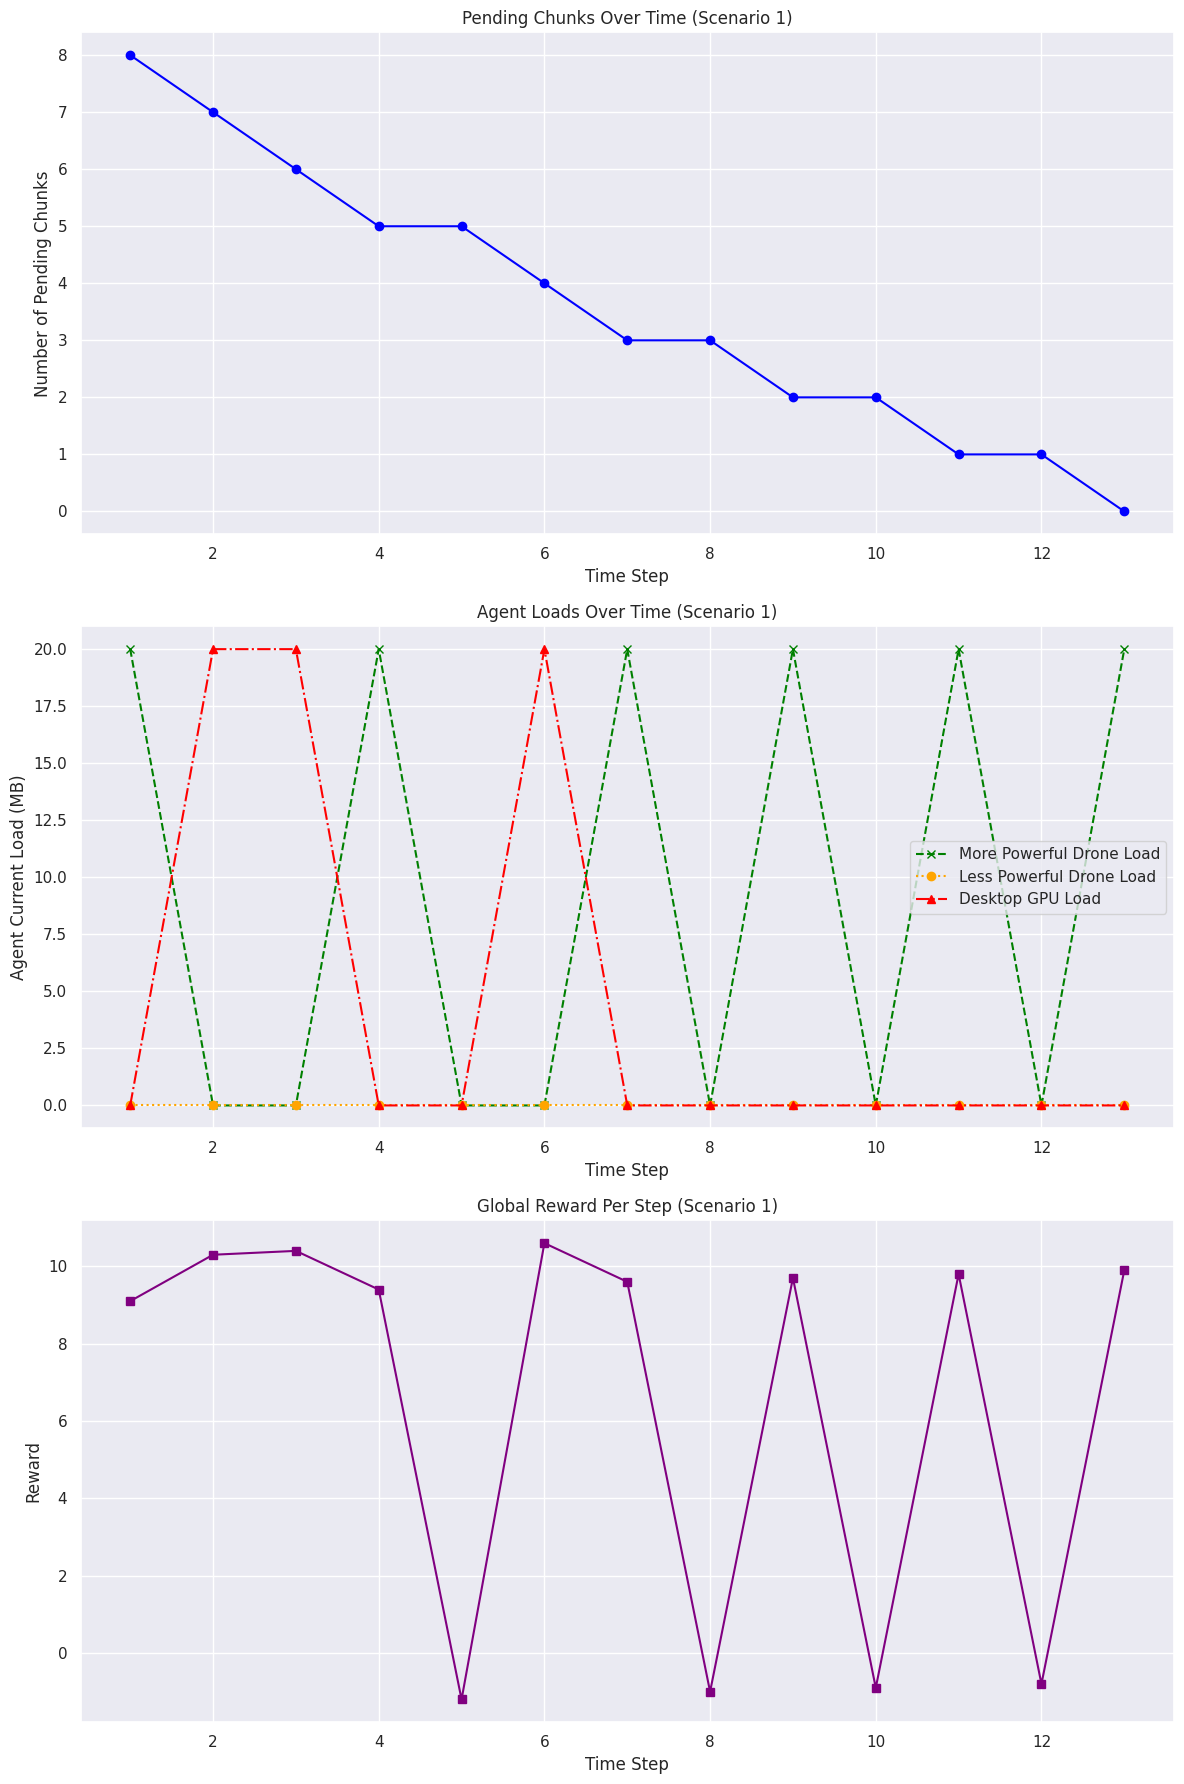

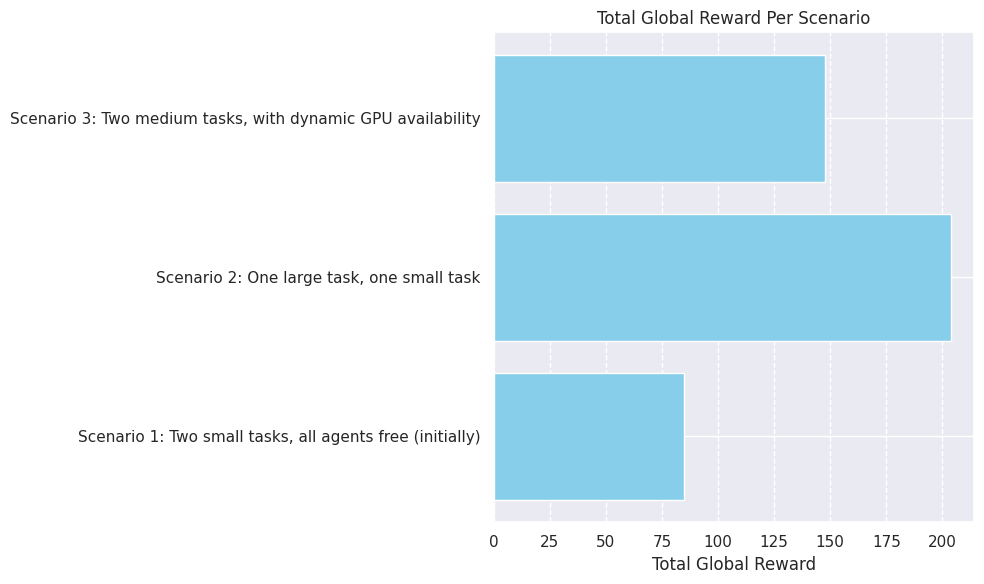

In [1]:
# -*- coding: utf-8 -*-
"""
# Stage 1 RL System: Drone Data Offloading Playground

This Jupyter Notebook provides a starting point for developing the Stage 1 of your Reinforcement Learning system.
The objective is to optimize where drone-captured data is offloaded and processed (onboard, edge, or cloud)
based on real-time network and system context.

This initial version focuses on:
-   Defining a simplified environment with specific agents.
-   Allowing agents to make offloading/processing decisions.
-   Calculating a global reward to encourage coordination.
-   Simulating decentralized execution.

**Note:** This code does NOT yet implement PPO or neural networks for the policies.
Agent decisions are based on simple heuristics and random choices for now.
It sets up the environment and simulation loop for you to integrate a sophisticated
RL algorithm like Multi-Agent Proximal Policy Optimization (MAPPO).

**Key Elements:**
-   **Environment (`OffloadingEnv`):** Manages tasks, agents, their loads, and global state.
-   **Agents (`Agent` class):** Represents individual decision-makers (drones, GPU).
-   **Simulation Loop:** Runs scenarios and logs events.
-   **Basic Visualization:** Plots key metrics for a scenario.
"""

import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import seaborn as sns
import gym # Import gym for defining observation/action spaces (crucial for RL libraries)
from gym import spaces

sns.set_theme()

# --- 1. Environment Definition ---

class OffloadingEnv(gym.Env): # Inherit from gym.Env for compatibility with RL libraries
    """
    Simulates the environment for drone data offloading.
    Agents: More Powerful Drone, Less Powerful Drone, Desktop GPU (Ground Station).
    Cloud is considered a fallback processing option.
    """
    metadata = {'render_modes': ['human'], 'render_fps': 4} # Required for gym.Env

    def __init__(self, initial_chunks_per_task=[5, 4], chunk_size_mb=20.0,
                 mpd_processing_speed=2.0, lpd_processing_speed=1.0,
                 gpu_processing_speed=5.0, gpu_busy_chance=0.2):
        super(OffloadingEnv, self).__init__() # Initialize parent class

        self.agents = ["More Powerful Drone", "Less Powerful Drone", "Desktop GPU"]
        self.num_agents = len(self.agents)

        self.initial_chunks_per_task = initial_chunks_per_task
        self.chunk_size_mb = chunk_size_mb

        # Agent capacities and current load (simulated processing time/busy-ness)
        self.agent_speeds = {
            "More Powerful Drone": mpd_processing_speed, # MB/step
            "Less Powerful Drone": lpd_processing_speed, # MB/step
            "Desktop GPU": gpu_processing_speed          # MB/step
        }
        self.agent_max_loads = {
            "More Powerful Drone": 20.0, # Can process 20MB chunk at once
            "Less Powerful Drone": 10.0, # Can process 10MB chunk at once
            "Desktop GPU": 40.0         # Can process 40MB chunk at once
        }

        # Cloud as a fallback option - not an active agent but a target for offloading
        # Later, an agent could have an action to "offload to cloud"
        self.cloud_latency_penalty = 0.5 # Penalty per chunk processed by cloud
        self.cloud_cost_penalty = 0.3    # Penalty per chunk processed by cloud

        self.gpu_busy_chance = gpu_busy_chance # Chance GPU is unavailable each step

        # Define observation space (crucial for RL algorithms)
        # State vector: [num_active_tasks, pending_chunks,
        #                 mpd_load, lpd_load, gpu_load, desktop_gpu_is_busy,
        #                 next_chunk_size_mb, next_chunk_task_id (one-hot or index)]
        # Assuming max 2 tasks (A, B) for next_chunk_task_id simplicity.
        # Max chunks could be 20 for initial scenarios. Max load based on capacities.
        high_values = np.array([
            len(initial_chunks_per_task) + 1, # Max possible active tasks
            sum(initial_chunks_per_task) + 1, # Max possible pending chunks
            self.agent_max_loads["More Powerful Drone"],
            self.agent_max_loads["Less Powerful Drone"],
            self.agent_max_loads["Desktop GPU"],
            1, # desktop_gpu_is_busy (0 or 1)
            self.chunk_size_mb + 1, # Max chunk size
            len(initial_chunks_per_task) # Max task ID index
        ], dtype=np.float32)

        self.observation_space = spaces.Box(low=0, high=high_values, shape=(8,), dtype=np.float32)

        # Define action space for EACH agent (0: IGNORE, 1: PROCESS_CHUNK)
        # In a multi-agent setting, the RL framework will handle joint actions
        self.action_space = spaces.Discrete(2) # Each agent chooses one of 2 actions

        # Initialize environment state
        self.reset()

    def _initialize_tasks(self, chunks_per_task_list):
        tasks = {}
        for i, num_chunks in enumerate(chunks_per_task_list):
            task_id = f"Task {chr(65 + i)}" # Task A, Task B, etc.
            # For simplicity, all chunks are initial_chunk_size_mb for now.
            # You can make this dynamic or mixed later.
            chunks = deque([{'size_mb': self.chunk_size_mb, 'task_id': task_id} for _ in range(num_chunks)])
            tasks[task_id] = chunks
        return tasks

    def _update_agent_loads(self):
        """Simulate reduction in agent load as processing completes."""
        for agent in self.agents:
            if self.agent_loads[agent] > 0:
                self.agent_loads[agent] = max(0, self.agent_loads[agent] - self.agent_speeds[agent])

        # Simulate GPU becoming busy/free dynamically
        self.desktop_gpu_is_busy = (random.random() < self.gpu_busy_chance)


    def _get_obs(self):
        """
        Returns the current observation for the agents.
        This will be the input to the policy network.
        """
        num_active_tasks = len([q for q in self.task_queues.values() if len(q) > 0])
        pending_chunks = sum(len(q) for q in self.task_queues.values())

        # Get the next chunk available for processing without removing it
        next_chunk_info = None
        for task_id in sorted(self.task_queues.keys()): # Iterate deterministically
            if self.task_queues[task_id]:
                next_chunk_info = self.task_queues[task_id][0]
                break

        # State vector: [num_active_tasks, pending_chunks,
        #                 mpd_load, lpd_load, gpu_load, gpu_is_busy,
        #                 next_chunk_size_mb, next_chunk_task_id_idx]

        # Default values if no next chunk
        next_chunk_size = 0.0
        next_chunk_task_idx = -1 # Sentinel value for no task

        if next_chunk_info:
            next_chunk_size = next_chunk_info['size_mb']
            next_chunk_task_idx = (ord(next_chunk_info['task_id'][-1]) - ord('A')) # 0 for A, 1 for B etc.

        observation = np.array([
            num_active_tasks,
            pending_chunks,
            self.agent_loads["More Powerful Drone"],
            self.agent_loads["Less Powerful Drone"],
            self.agent_loads["Desktop GPU"],
            1 if self.desktop_gpu_is_busy else 0,
            next_chunk_size,
            next_chunk_task_idx
        ], dtype=np.float32)

        return observation

    def step(self, actions_dict): # actions_dict maps agent_name to action_index (0 or 1)
        """
        Applies actions from all agents and updates the environment.
        Args:
            actions_dict (dict): A dictionary mapping agent_name to their chosen action (0:IGNORE, 1:PROCESS_CHUNK).
        Returns:
            tuple: (observation, global_reward, terminated, truncated, info) for gym API
        """
        self.time_step += 1
        self._update_agent_loads() # Reduce current load, potentially make GPU busy

        global_reward = 0
        processed_this_step = False
        outcome_log = {}

        # Sort agents to ensure deterministic processing order if multiple agents choose to process
        sorted_agents = sorted(self.agents)

        # Find the first available chunk for this step
        current_chunk = None
        current_task_id = None
        for task_id in sorted(self.task_queues.keys()):
            if self.task_queues[task_id]:
                current_chunk = self.task_queues[task_id][0] # Peek at the chunk
                current_task_id = task_id
                break

        if current_chunk:
            # Find an agent that decided to PROCESS_CHUNK AND is capable/available
            chosen_agent_for_chunk = None

            # This logic dictates which agent "wins" the chunk if multiple agents try to process.
            # In a true MAPPO, the policy should learn this coordination without explicit rules here,
            # but for a playground, this helps simulate observed behavior or desired arbitration.

            # Prioritize based on capabilities / efficiency, or simply first agent to claim it.
            # Here, we iterate through agents in a specific order for arbitration

            for agent_name in sorted_agents:
                action_idx = actions_dict.get(agent_name)
                action_str = "PROCESS_CHUNK" if action_idx == 1 else "IGNORE"
                outcome_log[agent_name] = action_str

                if action_str == "PROCESS_CHUNK":
                    # Check if agent is capable and available
                    can_process = True
                    if self.agent_loads[agent_name] > 0: # Agent is currently busy processing another chunk
                        can_process = False
                    elif agent_name == "Less Powerful Drone" and current_chunk['size_mb'] > self.agent_max_loads["Less Powerful Drone"]:
                        can_process = False # LPD can't handle large chunks
                    elif agent_name == "Desktop GPU" and self.desktop_gpu_is_busy:
                        can_process = False # GPU is explicitly busy

                    if can_process:
                        chosen_agent_for_chunk = agent_name
                        break # This agent successfully claimed the chunk

            if chosen_agent_for_chunk:
                # The chosen agent processes the chunk
                chunk_processed = self.task_queues[current_task_id].popleft()
                # Agent load increases temporarily, will decrease in _update_agent_loads
                self.agent_loads[chosen_agent_for_chunk] += chunk_processed['size_mb']
                self.processed_chunks_count += 1
                global_reward += 10 # Reward for processing a chunk (core objective)
                processed_this_step = True
                outcome_log["OUTCOME"] = f"Processed by {chosen_agent_for_chunk}"

                # Apply penalties/bonuses based on who processed it to guide learning
                if chosen_agent_for_chunk == "Less Powerful Drone":
                    global_reward += 2 # Bonus for using a less powerful agent (encourages load distribution)
                elif chosen_agent_for_chunk == "More Powerful Drone":
                    global_reward -= 0.1 # Small penalty to slightly discourage over-reliance
                elif chosen_agent_for_chunk == "Desktop GPU":
                    global_reward += 1 # Small bonus for using GPU (fast)
            else:
                outcome_log["OUTCOME"] = "No capable or willing agent processed chunk"
                global_reward -= 0.5 # Small penalty for not processing an available chunk
        else:
            outcome_log["OUTCOME"] = "No chunks left to process"


        # Penalize for remaining chunks (ongoing penalty for unfinished work)
        global_reward -= sum(len(q) for q in self.task_queues.values()) * 0.1

        # Penalize for idle agents if there are chunks to process (encourages utilization)
        if not processed_this_step and sum(len(q) for q in self.task_queues.values()) > 0:
            total_agent_capacity = sum(self.agent_max_loads[a] for a in self.agents if a != "Desktop GPU" or not self.desktop_gpu_is_busy)
            if total_agent_capacity > 0: # If there's capacity but no chunk was picked
                global_reward -= 0.2

        terminated = self.processed_chunks_count == self.total_initial_chunks
        truncated = self.time_step >= self.max_steps # For limiting simulation steps

        observation = self._get_obs()
        info = {"processed_this_step": processed_this_step, "outcome_log": outcome_log}

        self.history.append({"time_step": self.time_step, "state_obs": observation,
                             "agent_loads": self.agent_loads.copy(),
                             "actions": actions_dict, "reward": global_reward,
                             "terminated": terminated, "outcome": outcome_log["OUTCOME"]})

        return observation, global_reward, terminated, truncated, info

    def reset(self, initial_chunks_per_task=None, seed=None, options=None):
        """Resets the environment to an initial state."""
        if seed is not None: # For reproducibility with gym environments
            super().reset(seed=seed)
            random.seed(seed)
            np.random.seed(seed)

        self.time_step = 0
        self.processed_chunks_count = 0
        self.agent_loads = {agent: 0 for agent in self.agents}
        self.desktop_gpu_is_busy = False # Reset GPU busy state

        if initial_chunks_per_task is None:
            self.task_queues = self._initialize_tasks(self.initial_chunks_per_task)
        else:
            self.task_queues = self._initialize_tasks(initial_chunks_per_task)
            self.total_initial_chunks = sum(len(q) for q in self.task_queues.values())

        self.history = []
        self.max_steps = 100 # Default max steps for a scenario

        observation = self._get_obs()
        info = {} # Additional info for reset (optional)
        return observation, info

    # Minimal render function (optional for basic environments)
    def render(self):
        pass

    def close(self):
        pass


# --- 2. Agent Definition (for simulation, not actual PPO policy yet) ---

class Agent:
    """
    Represents a single learning agent.
    In a full PPO setup, this would contain the neural network policy.
    For now, it's a placeholder with simple heuristic decision-making.
    """
    def __init__(self, name, capabilities=None):
        self.name = name
        self.capabilities = capabilities if capabilities else {}
        # Placeholder for a neural network policy later
        # self.policy_net = ...

    def choose_action(self, observation, env_agent_loads, env_desktop_gpu_is_busy):
        """
        Chooses an action based on observation and internal state.
        For this playground, it uses simple heuristics.
        Returns an action index (0: IGNORE, 1: PROCESS_CHUNK).
        """
        # Unpack relevant parts of the observation for heuristic decision
        # [num_active_tasks, pending_chunks, mpd_load, lpd_load, gpu_load, desktop_gpu_is_busy, next_chunk_size_mb, next_chunk_task_id_idx]
        current_load = env_agent_loads.get(self.name, 0)
        max_load = env.agent_max_loads.get(self.name, float('inf'))
        next_chunk_size = observation[6] # next_chunk_size_mb

        # Heuristic 1: If agent is fully loaded, ignore.
        if current_load >= max_load:
            return 0 # IGNORE

        # Heuristic 2: Desktop GPU won't try to process if it's busy
        if self.name == "Desktop GPU" and env_desktop_gpu_is_busy:
            return 0 # IGNORE

        # Heuristic 3: Less Powerful Drone won't try to process chunks larger than its max capacity
        if self.name == "Less Powerful Drone" and next_chunk_size > self.capabilities.get('max_chunk_mb', float('inf')):
             return 0 # IGNORE

        # If a specific agent is generally preferred and capable, give it a higher chance to PROCESS_CHUNK
        # These probabilities are arbitrary and designed to show some initial behavior,
        # which PPO would then learn and optimize.
        if self.name == "More Powerful Drone":
            return random.choices([1, 0], weights=[0.95, 0.05], k=1)[0] # High chance to process
        elif self.name == "Desktop GPU":
            return random.choices([1, 0], weights=[0.8, 0.2], k=1)[0] # Good chance if available
        elif self.name == "Less Powerful Drone":
            # LPD is less likely to process if larger chunks are around, more likely for small ones
            if next_chunk_size <= self.capabilities.get('max_chunk_mb', 0):
                return random.choices([1, 0], weights=[0.6, 0.4], k=1)[0] # Moderate chance if it can handle
            else:
                return 0 # IGNORE if chunk too big

        return 0 # Default IGNORE

# --- 3. Simulation Loop ---

def run_scenario(env, agents, scenario_name, initial_chunks, max_steps=100):
    """
    Runs a single simulation scenario.
    """
    print(f"\n============================================================")
    print(f"--- SCENARIO: {scenario_name} ---")
    print(f"============================================================")

    env.max_steps = max_steps # Set max steps for this scenario run
    obs, info = env.reset(initial_chunks_per_task=initial_chunks)
    print(f"  > Initial State: {obs[1]:.0f} chunks to process across {obs[0]:.0f} task queues.")

    terminated = False
    truncated = False
    step_count = 0
    total_reward = 0

    while not terminated and not truncated:
        step_count += 1

        # Get current state observation for all agents
        current_obs = env._get_obs() # Use internal _get_obs for agents' decisions

        # Display current chunk info
        next_chunk_size = current_obs[6]
        next_chunk_task_id_idx = int(current_obs[7])
        task_char = chr(65 + next_chunk_task_id_idx) if next_chunk_task_id_idx != -1 else 'N/A'
        print(f"\n    Step {step_count} (Next Chunk Size: {next_chunk_size}MB, Task: {task_char}):")

        actions = {} # Dictionary to store actions for this step from all agents
        for agent_obj in agents:
            # Each agent chooses an action based on the global observation
            action_idx = agent_obj.choose_action(
                current_obs,
                env.agent_loads,
                env.desktop_gpu_is_busy
            )
            actions[agent_obj.name] = action_idx
            action_str = "PROCESS_CHUNK" if action_idx == 1 else "IGNORE"
            print(f"      - {agent_obj.name} decision: {action_str}")

        # Environment takes the joint actions and returns the new state, reward, etc.
        obs, reward, terminated, truncated, info = env.step(actions)
        total_reward += reward

        print(f"      ==> OUTCOME: {info['outcome_log']['OUTCOME']}")

    if terminated:
        print(f"\n  --- SCENARIO {scenario_name} COMPLETE ---")
        print(f"  Total Chunks Processed: {env.processed_chunks_count}")
        print(f"  Total Steps: {env.time_step}")
        print(f"  Total Global Reward: {total_reward:.2f}")
    elif truncated:
        print(f"\n  --- SCENARIO {scenario_name} Halted (Max Steps Reached) ---")
        print(f"  Chunks Remaining: {obs[1]:.0f}")
        print(f"  Total Chunks Processed: {env.processed_chunks_count}")
        print(f"  Total Steps: {env.time_step}")
        print(f"  Total Global Reward: {total_reward:.2f}")

    return env.history, total_reward

# --- 4. Main Execution in Jupyter ---

if __name__ == "__main__":
    # Instantiate the environment
    # Adjust speeds and busy chance to experiment with different dynamics
    env = OffloadingEnv(
        mpd_processing_speed=20.0, # More Powerful Drone is fast
        lpd_processing_speed=5.0,  # Less Powerful Drone is slower
        gpu_processing_speed=40.0, # Desktop GPU is very fast
        gpu_busy_chance=0.3        # 30% chance GPU is busy each step
    )

    # Instantiate agents
    # Define capabilities that influence their heuristic decisions (e.g., max chunk size)
    mp_drone = Agent("More Powerful Drone", capabilities={"max_chunk_mb": 20.0})
    lp_drone = Agent("Less Powerful Drone", capabilities={"max_chunk_mb": 10.0}) # Can only process smaller chunks
    desktop_gpu = Agent("Desktop GPU", capabilities={"max_chunk_mb": 40.0})

    all_agents = [mp_drone, lp_drone, desktop_gpu]

    # --- Define Scenarios ---
    scenarios = [
        {"name": "Scenario 1: Two small tasks, all agents free (initially)", "chunks": [5, 4]}, # Total 9 chunks
        {"name": "Scenario 2: One large task, one small task", "chunks": [15, 8]}, # Total 23 chunks
        {"name": "Scenario 3: Two medium tasks, with dynamic GPU availability", "chunks": [8, 8]}, # Total 16 chunks
    ]

    scenario_results = {}

    for scenario_params in scenarios:
        history, final_reward = run_scenario(
            env,
            all_agents,
            scenario_params["name"],
            scenario_params["chunks"],
            max_steps=50 # Set a reasonable max steps to prevent infinite loops
        )
        scenario_results[scenario_params["name"]] = {"history": history, "final_reward": final_reward}

    print("\n--- Simulation Complete ---")

    # --- 5. Basic Visualization (Example) ---
    print("\n--- Visualizing Scenario 1 ---")
    scenario1_history = scenario_results[scenarios[0]["name"]]["history"]

    # Extract data for plotting
    time_steps = [entry['time_step'] for entry in scenario1_history]
    pending_chunks = [entry['state_obs'][1] for entry in scenario1_history] # Index 1 is pending_chunks
    mpd_loads = [entry['agent_loads']["More Powerful Drone"] for entry in scenario1_history]
    lpd_loads = [entry['agent_loads']["Less Powerful Drone"] for entry in scenario1_history]
    gpu_loads = [entry['agent_loads']["Desktop GPU"] for entry in scenario1_history]
    rewards = [entry['reward'] for entry in scenario1_history]

    fig, axes = plt.subplots(3, 1, figsize=(12, 18))

    # Plot 1: Pending Chunks Over Time
    axes[0].plot(time_steps, pending_chunks, marker='o', linestyle='-', color='blue')
    axes[0].set_title('Pending Chunks Over Time (Scenario 1)')
    axes[0].set_xlabel('Time Step')
    axes[0].set_ylabel('Number of Pending Chunks')
    axes[0].grid(True)

    # Plot 2: Agent Loads Over Time
    axes[1].plot(time_steps, mpd_loads, label='More Powerful Drone Load', marker='x', linestyle='--', color='green')
    axes[1].plot(time_steps, lpd_loads, label='Less Powerful Drone Load', marker='o', linestyle=':', color='orange')
    axes[1].plot(time_steps, gpu_loads, label='Desktop GPU Load', marker='^', linestyle='-.', color='red')
    axes[1].set_title('Agent Loads Over Time (Scenario 1)')
    axes[1].set_xlabel('Time Step')
    axes[1].set_ylabel('Agent Current Load (MB)')
    axes[1].legend()
    axes[1].grid(True)

    # Plot 3: Global Reward Per Step
    axes[2].plot(time_steps, rewards, marker='s', linestyle='-', color='purple')
    axes[2].set_title('Global Reward Per Step (Scenario 1)')
    axes[2].set_xlabel('Time Step')
    axes[2].set_ylabel('Reward')
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

    # You can extend this visualization section to include other scenarios or more detailed metrics.
    # For instance, plot total reward per scenario.
    scenario_names = [s["name"] for s in scenarios]
    final_rewards = [scenario_results[name]["final_reward"] for name in scenario_names]

    plt.figure(figsize=(10, 6))
    plt.barh(scenario_names, final_rewards, color='skyblue')
    plt.xlabel('Total Global Reward')
    plt.title('Total Global Reward Per Scenario')
    plt.grid(axis='x', linestyle='--')
    plt.tight_layout()
    plt.show()